# Loading Dataset and CNN
*Rolando A. Pula*

This notebook is a runnable version of the "Loading Dataset and CNN" slide deck. It walks through:

1. Loading a Dogs vs. Cats image dataset with OpenCV
2. Preprocessing the images (grayscale, resize, shuffle)
3. Saving/loading the prepared data with `pickle`
4. Building and training a Convolutional Neural Network (CNN) with TensorFlow/Keras to classify dogs vs. cats

> **Before you run this notebook:** download the Kaggle "Dogs vs. Cats" dataset (e.g. `https://www.kaggle.com/c/dogs-vs-cats/data` or the mirrored `salader/dogs-vs-cats` dataset on Kaggle) and unzip it so you have two folders, `Dog/` and `Cat/`, each full of `.jpg` images. Then set `DATADIR` below to point at the parent folder that contains `Dog/` and `Cat/`.

## Requirements for Image Processing

- **GPU** (optional, speeds up training but not required)
- **OpenCV** (`cv2`) – for image processing
- **os module** – lets Python interface with the OS running on your computer (already in the standard library)
- **Data** – we'll use the Kaggle "Dogs vs. Cats" dataset

Run the cell below once to install the packages this notebook needs (skip it if they're already installed in your environment).

In [ ]:
# Run this once if the packages below aren't already installed.
# %pip install opencv-python numpy matplotlib tensorflow

## Checking and installing OpenCV

The original slides show installing OpenCV through **Anaconda Navigator** (Environments tab → search `opencv` → Install). If you're not using Anaconda, the `pip install opencv-python` command in the cell above does the same thing.

## Calling the Necessary Modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
import random
import tensorflow as tf

# ---------------------------------------------------------
# REPRODUCIBILITY
# ---------------------------------------------------------
# Using fixed random seeds helps make the experiment
# reproducible when the notebook is rerun.
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"Random seed set to: {SEED}")

Random seed set to: 42


## Data Preparation

Set `DATADIR` to the folder on your machine that contains the `Dog` and `Cat` subfolders (this replaces the original slide's hard-coded Windows path, `C:/Users/admin/Desktop/AMEN/Deep_Learning_class/Kaggle_dataset/PetImages`, with something you can edit for your own machine).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## Unzipping the Dataset

Given that the dataset is in a `.zip` file in Google Drive, we need to unzip it to a local directory before processing. I'll unzip `PetImages.zip` to `/content/` and then set `DATADIR` to this new location.

In [ ]:
import zipfile
import os

# Path to the zip file in Google Drive

zip_file_path = '/content/drive/MyDrive/PetImages.zip'

# Destination directory to unzip the files
destination_dir = '/content/'

# Create the destination directory if it doesn't exist
os.makedirs(destination_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(destination_dir)

print(f"Unzipped '{zip_file_path}' to '{destination_dir}'")

# The dataset will be unzipped into a folder named 'PetImages' inside destination_dir
# Update DATADIR to point to this unzipped location

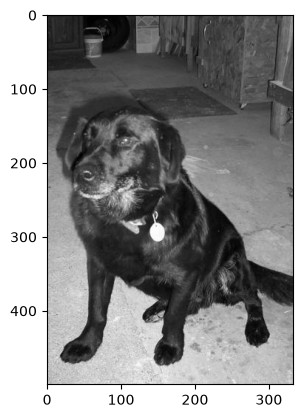

In [2]:
DATADIR = "/Users/joprisseolfindo/Documents/Bioinformatics/Datasets/PetImages"  # <- change this to the path that contains your Dog/ and Cat/ folders
# this is the directory of your datasets
CATEGORIES = ["Dog", "Cat"]   # Defining the label as "Dog" or "Cat"

for category in CATEGORIES:
    path = os.path.join(DATADIR, category)  # path to cats or dogs dir
    for img in os.listdir(path):
        img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
        if img_array is None:
            # a handful of files in the Kaggle dataset are corrupted/unreadable - skip them
            continue

        # reading the image in the path and transforming it into an array
        # cv2.IMREAD_GRAYSCALE converts the image to grayscale so the CNN only has
        # to learn from one color channel instead of three (faster, smaller model)

        plt.imshow(img_array, cmap="gray")
        plt.show()
        break
    break

## Image Inspection

In [3]:
print(img_array)          # Displaying the image in array form (just for checking)
print(img_array.shape)    # checking the resolution of the image

[[ 41  42  43 ... 123 138 135]
 [ 39  40  41 ... 133 143 136]
 [ 40  41  41 ... 139 145 135]
 ...
 [207 194 213 ... 207 198 188]
 [203 190 212 ... 202 191 184]
 [172 168 204 ... 195 182 179]]
(500, 333)


## Image Resizing

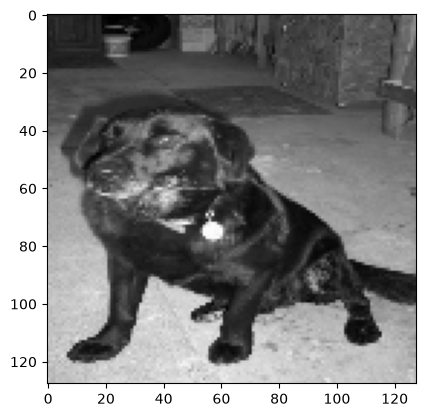

In [4]:
IMG_SIZE = 128  # initializing variable "IMG_SIZE" as 100

new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
plt.imshow(new_array, cmap='gray')
plt.show()

## Assigning Training Data

In [5]:
training_data = []  # assigning training data

def create_training_data():
    for category in CATEGORIES:
        path = os.path.join(DATADIR, category)  # path to cats or dogs dir
        class_num = CATEGORIES.index(category)
        for img in sorted(os.listdir(path)):
            try:
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
                new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                training_data.append([new_array, class_num])
            except Exception as e:
                pass

create_training_data()

Corrupt JPEG data: 402 extraneous bytes before marker 0xd9
Corrupt JPEG data: 232 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1 extraneous bytes before marker 0xd9
Corrupt JPEG data: 164 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1408 extraneous bytes before marker 0xd9
Corrupt JPEG data: 259 extraneous bytes before marker 0xd9
Corrupt JPEG data: 2232 extraneous bytes before marker 0xd9
Corrupt JPEG data: 70 extraneous bytes before marker 0xd9
Corrupt JPEG data: 242 extraneous bytes before marker 0xd9
Corrupt JPEG data: 217 extraneous bytes before marker 0xd9
Corrupt JPEG data: 133 extraneous bytes before marker 0xd9
Corrupt JPEG data: 104 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1158 extraneous bytes before marker 0xd9


## Checking the Number of Training Data

In [6]:
print(len(training_data))

24997


## Randomizing/Shuffling the Data

In [7]:
random.shuffle(training_data)

for sample in training_data[:10]:
    print(sample[1])

0
0
1
0
1
0
1
1
1
0


## Assigning Variables for Features and Labels

In [8]:
X = []  # feature set
y = []  # labels

for features, label in training_data:
    X.append(features)
    y.append(label)

X = np.array(X).reshape(-1, IMG_SIZE, IMG_SIZE, 1)  # 1 is for grayscale
y = np.array(y)  # Keras expects the labels as an array too

## Using the Pickle Module

In [9]:
import pickle  # pickle lets you save your training data, avoiding recreating it
                # from scratch every time you want to adjust the model

with open('X.pickle', 'wb') as f:
    pickle.dump(X, f)

with open('y.pickle', 'wb') as g:
    pickle.dump(y, g)

## Using Pickle (Loading It Back)

In [10]:
pickle_in = open('X.pickle', 'rb')
X = pickle.load(pickle_in)

X[1]

array([[[210],
        [209],
        [216],
        ...,
        [228],
        [228],
        [226]],

       [[210],
        [209],
        [214],
        ...,
        [228],
        [228],
        [226]],

       [[210],
        [209],
        [212],
        ...,
        [228],
        [228],
        [226]],

       ...,

       [[ 73],
        [ 83],
        [ 90],
        ...,
        [129],
        [129],
        [131]],

       [[ 85],
        [ 82],
        [ 79],
        ...,
        [130],
        [141],
        [138]],

       [[ 64],
        [ 88],
        [ 78],
        ...,
        [136],
        [137],
        [132]]], dtype=uint8)

## What is a CNN?

**CNN** stands for **Convolutional Neural Network** — a type of neural network especially well suited to image data because it learns spatial patterns (edges, textures, shapes) through convolution and pooling layers instead of treating every pixel independently.

Further reading:
- https://medium.com/data-science-group-iitr/building-a-convolutional-neural-network-in-python-with-tensorflow-d251c3ca8117
- https://hackernoon.com/what-is-a-capsnet-or-capsule-network-2bfbe48769cc

## Using a CNN for Classification of Images

In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D
import pickle

X = pickle.load(open('X.pickle', 'rb'))
y = pickle.load(open('y.pickle', 'rb'))

## Building, Compiling, and Training the CNN

`X = X/255.0` normalizes the pixel values (0-255) down to the 0-1 range, which helps the network train faster and more stably.

> Training for the full 200 epochs on the whole dataset can take a long time on CPU. Reduce `epochs` (e.g. to 10) for a quick test run, and increase it back up once you know the pipeline works.

In [ ]:
## Model Preparation

In [12]:
# =========================================================
# STEP 1: NORMALIZE THE IMAGE DATA
# =========================================================

X = X.astype(np.float32) / 255.0

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Pixel range:", X.min(), "to", X.max())



X shape: (24997, 128, 128, 1)
y shape: (24997,)
Pixel range: 0.0 to 1.0


In [13]:
# =========================================================
# STEP 2: CREATE TRAIN / VALIDATION / TEST SETS
# =========================================================

from sklearn.model_selection import train_test_split

# ---------------------------------------------------------
# First split:
# Reserve 10% of the complete dataset as the FINAL TEST SET.
#
# The model will NOT train on X_test / y_test.
# ---------------------------------------------------------

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X,
    y,
    test_size=0.10,
    random_state=SEED,
    stratify=y
)

# ---------------------------------------------------------
# Second split:
# From the remaining 90%, reserve 20% for validation.
#
# Final approximate proportions:
# Training   = 72%
# Validation = 18%
# Testing    = 10%
# ---------------------------------------------------------

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=0.20,
    random_state=SEED,
    stratify=y_trainval
)

print("========================================")
print("DATASET SPLIT")
print("========================================")

print(f"Total samples:      {len(X):,}")
print(f"Training samples:   {len(X_train):,}")
print(f"Validation samples: {len(X_val):,}")
print(f"Testing samples:    {len(X_test):,}")

print("\nShapes:")
print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

print("\nClass distribution:")

print(
    "Training - Dogs:",
    np.sum(y_train == 0),
    "| Cats:",
    np.sum(y_train == 1)
)

print(
    "Validation - Dogs:",
    np.sum(y_val == 0),
    "| Cats:",
    np.sum(y_val == 1)
)

print(
    "Testing - Dogs:",
    np.sum(y_test == 0),
    "| Cats:",
    np.sum(y_test == 1)
)

DATASET SPLIT
Total samples:      24,997
Training samples:   17,997
Validation samples: 4,500
Testing samples:    2,500

Shapes:
X_train: (17997, 128, 128, 1)
X_val:   (4500, 128, 128, 1)
X_test:  (2500, 128, 128, 1)

Class distribution:
Training - Dogs: 8999 | Cats: 8998
Validation - Dogs: 2250 | Cats: 2250
Testing - Dogs: 1250 | Cats: 1250


In [14]:
# =========================================================
# STEP 3: BUILD THE CNN MODEL
# =========================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    Activation,
    Flatten,
    Conv2D,
    MaxPooling2D
)

model = Sequential()

# Notice:
# We now use X_train.shape rather than X.shape
model.add(Input(shape=X_train.shape[1:]))

# Convolution Layer 1
model.add(Conv2D(2, (3, 3)))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Convolution Layer 2
model.add(Conv2D(64, (3, 3)))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Convolution Layer 3
model.add(Conv2D(64, (3, 3)))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Fully Connected Layers
model.add(Flatten())

model.add(Dense(64))
model.add(Dense(64))

# Binary Output Layer
model.add(Dense(1))
model.add(Activation("sigmoid"))

# Compile model
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

print("CNN model created successfully.")

CNN model created successfully.


In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 2)    │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 126, 126, 2)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 2)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 61, 61, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 845,269 (3.22 MB)

 Trainable params: 845,269 (3.22 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# =========================================================
# STEP 4: TRAIN THE FINAL SELECTED MODEL
# =========================================================

history = model.fit(
    X_train,
    y_train,

    batch_size=128,
    epochs=7,

    validation_data=(
        X_val,
        y_val
    ),

    verbose=1
)

Epoch 1/7
141/141 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - accuracy: 0.5973 - loss: 0.6657 - val_accuracy: 0.6682 - val_loss: 0.6144
Epoch 2/7
141/141 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.6964 - loss: 0.5805 - val_accuracy: 0.7289 - val_loss: 0.5453
Epoch 3/7
141/141 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.7417 - loss: 0.5254 - val_accuracy: 0.7609 - val_loss: 0.5044
Epoch 4/7
141/141 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - accuracy: 0.7684 - loss: 0.4838 - val_accuracy: 0.7773 - val_loss: 0.4745
Epoch 5/7
141/141 ━━━━━━━━━━━━━━━━━━━━ 11s 80ms/step - accuracy: 0.7924 - loss: 0.4459 - val_accuracy: 0.7838 - val_loss: 0.4726
Epoch 6/7
141/141 ━━━━━━━━━━━━━━━━━━━━ 11s 81ms/step - accuracy: 0.8057 - loss: 0.4203 - val_accuracy: 0.7876 - val_loss: 0.4693
Epoch 7/7
141/141 ━━━━━━━━━━━━━━━━━━━━ 11s 81ms/step - accuracy: 0.8264 - loss: 0.3857 - val_accuracy: 0.7949 - val_loss: 0.4768


In [17]:
# =========================================================
# STEP 5: DISPLAY FINAL TRAINING / VALIDATION RESULTS
# =========================================================

final_train_accuracy = history.history['accuracy'][-1]
final_val_accuracy = history.history['val_accuracy'][-1]

final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

best_val_accuracy = max(history.history['val_accuracy'])
best_val_epoch = (
    np.argmax(history.history['val_accuracy']) + 1
)

lowest_val_loss = min(history.history['val_loss'])
lowest_val_loss_epoch = (
    np.argmin(history.history['val_loss']) + 1
)

print("========================================")
print("TRAINING AND VALIDATION RESULTS")
print("========================================")

print(
    f"Final Training Accuracy:   "
    f"{final_train_accuracy * 100:.2f}%"
)

print(
    f"Final Validation Accuracy: "
    f"{final_val_accuracy * 100:.2f}%"
)

print(
    f"Final Training Loss:       "
    f"{final_train_loss:.4f}"
)

print(
    f"Final Validation Loss:     "
    f"{final_val_loss:.4f}"
)

print("\nBest Validation Performance:")

print(
    f"Best Validation Accuracy: "
    f"{best_val_accuracy * 100:.2f}% "
    f"(Epoch {best_val_epoch})"
)

print(
    f"Lowest Validation Loss: "
    f"{lowest_val_loss:.4f} "
    f"(Epoch {lowest_val_loss_epoch})"
)

TRAINING AND VALIDATION RESULTS
Final Training Accuracy:   82.64%
Final Validation Accuracy: 79.49%
Final Training Loss:       0.3857
Final Validation Loss:     0.4768

Best Validation Performance:
Best Validation Accuracy: 79.49% (Epoch 7)
Lowest Validation Loss: 0.4693 (Epoch 6)


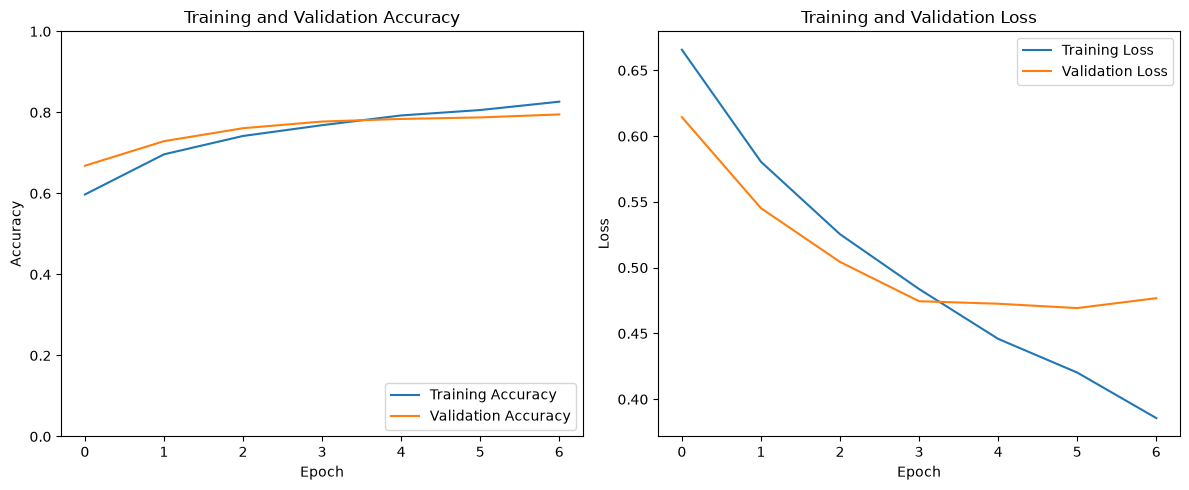

In [18]:
# =========================================================
# STEP 6: TRAINING AND VALIDATION CURVES
# =========================================================

plt.figure(figsize=(12, 5))

# ---------------------------------------------------------
# Accuracy
# ---------------------------------------------------------

plt.subplot(1, 2, 1)

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')

plt.title(
    'Training and Validation Accuracy'
)

# ---------------------------------------------------------
# Loss
# ---------------------------------------------------------

plt.subplot(1, 2, 2)

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.title(
    'Training and Validation Loss'
)

plt.tight_layout()
plt.show()

In [19]:
# =========================================================
# STEP 7: FINAL EVALUATION ON UNSEEN TEST DATA
# =========================================================

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("\n========================================")
print("FINAL TEST RESULTS")
print("========================================")

print(
    f"Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

print(
    f"Test Loss: "
    f"{test_loss:.4f}"
)

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7768 - loss: 0.4940

FINAL TEST RESULTS
Test Accuracy: 77.68%
Test Loss: 0.4940


In [20]:
# =========================================================
# STEP 8: TEST-SET CLASSIFICATION METRICS
# =========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Model probabilities
y_pred_proba = model.predict(
    X_test,
    verbose=0
).ravel()

# Convert probability into class prediction
#
# < 0.5 = Dog
# >= 0.5 = Cat
y_pred = (
    y_pred_proba >= 0.5
).astype(int)

# ---------------------------------------------------------
# Calculate metrics
# ---------------------------------------------------------

test_accuracy_manual = accuracy_score(
    y_test,
    y_pred
)

precision_macro = precision_score(
    y_test,
    y_pred,
    average='macro'
)

recall_macro = recall_score(
    y_test,
    y_pred,
    average='macro'
)

f1_macro = f1_score(
    y_test,
    y_pred,
    average='macro'
)

print("========================================")
print("TEST-SET CLASSIFICATION METRICS")
print("========================================")

print(
    f"Test Accuracy:   "
    f"{test_accuracy_manual * 100:.2f}%"
)

print(
    f"Macro Precision: "
    f"{precision_macro:.4f}"
)

print(
    f"Macro Recall:    "
    f"{recall_macro:.4f}"
)

print(
    f"Macro F1-score:  "
    f"{f1_macro:.4f}"
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Dog",
            "Cat"
        ],
        digits=4
    )
)

TEST-SET CLASSIFICATION METRICS
Test Accuracy:   77.68%
Macro Precision: 0.7795
Macro Recall:    0.7768
Macro F1-score:  0.7763

Classification Report:

              precision    recall  f1-score   support

         Dog     0.8067    0.7280    0.7653      1250
         Cat     0.7522    0.8256    0.7872      1250

    accuracy                         0.7768      2500
   macro avg     0.7795    0.7768    0.7763      2500
weighted avg     0.7795    0.7768    0.7763      2500



Confusion Matrix:
[[ 910  340]
 [ 218 1032]]


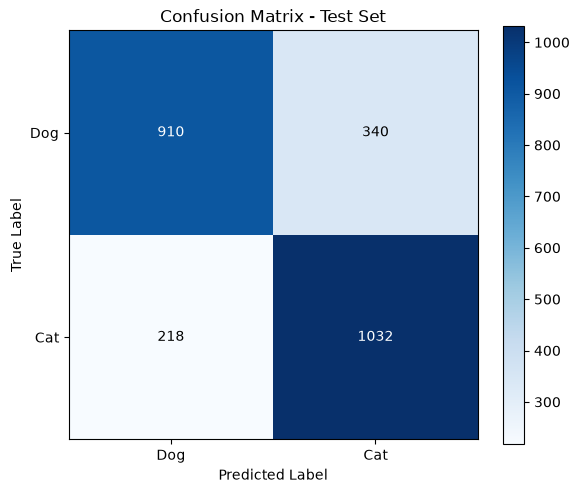

In [21]:
# =========================================================
# STEP 9: CONFUSION MATRIX — TEST SET ONLY
# =========================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

plt.figure(
    figsize=(6, 5)
)

plt.imshow(
    cm,
    interpolation='nearest',
    cmap=plt.cm.Blues
)

plt.title(
    'Confusion Matrix - Test Set'
)

plt.colorbar()

CATEGORIES = [
    "Dog",
    "Cat"
]

tick_marks = np.arange(
    len(CATEGORIES)
)

plt.xticks(
    tick_marks,
    CATEGORIES
)

plt.yticks(
    tick_marks,
    CATEGORIES
)

plt.ylabel(
    'True Label'
)

plt.xlabel(
    'Predicted Label'
)

threshold = cm.max() / 2

for i, j in np.ndindex(
    cm.shape
):
    plt.text(
        j,
        i,
        format(cm[i, j], 'd'),
        horizontalalignment='center',
        verticalalignment='center',
        color=(
            "white"
            if cm[i, j] > threshold
            else "black"
        )
    )

plt.tight_layout()
plt.show()

Test ROC-AUC: 0.8584


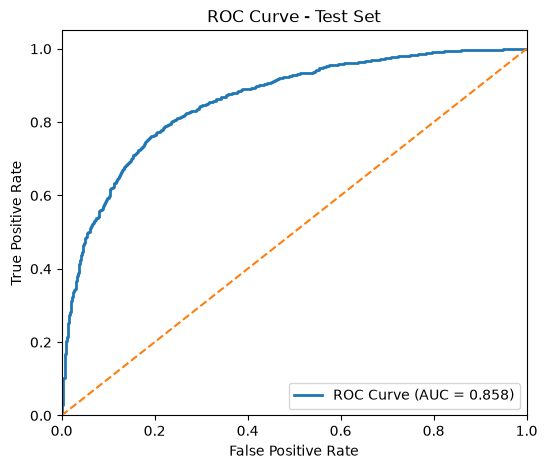

In [22]:
# =========================================================
# STEP 10: ROC CURVE AND AUC — TEST SET ONLY
# =========================================================

from sklearn.metrics import (
    roc_curve,
    auc
)

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_pred_proba
)

roc_auc = auc(
    fpr,
    tpr
)

print(
    f"Test ROC-AUC: "
    f"{roc_auc:.4f}"
)

plt.figure(
    figsize=(6, 5)
)

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=(
        f'ROC Curve '
        f'(AUC = {roc_auc:.3f})'
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlim([
    0.0,
    1.0
])

plt.ylim([
    0.0,
    1.05
])

plt.xlabel(
    'False Positive Rate'
)

plt.ylabel(
    'True Positive Rate'
)

plt.title(
    'ROC Curve - Test Set'
)

plt.legend(
    loc='lower right'
)

plt.show()

In [23]:
# =========================================================
# FINAL MODEL SUMMARY FOR HYPERPARAMETER SELECTION FORM
# =========================================================

print("============================================")
print("FINAL CNN MODEL — DOGS VS. CATS")
print("============================================")

print("\nHYPERPARAMETERS")
print("--------------------------------------------")
print(f"Image Size:           {IMG_SIZE} x {IMG_SIZE}")
print("Color Mode:           Grayscale")
print("Normalization:        X / 255.0")
print("Conv2D Filters:       2, 64, 64")
print("Kernel Size:          (3, 3)")
print("Pooling:              MaxPooling2D (2, 2)")
print("Dense Units:          64, 64")
print("Output Activation:    Sigmoid")
print("Optimizer:            Adam")
print("Loss Function:        Binary Crossentropy")
print("Batch Size:           128")
print("Epochs:               7")
print("Early Stopping:       No")

print("\nDATA SPLIT")
print("--------------------------------------------")
print(f"Training Samples:     {len(X_train):,}")
print(f"Validation Samples:   {len(X_val):,}")
print(f"Test Samples:         {len(X_test):,}")

print("\nFINAL RESULTS")
print("--------------------------------------------")

print(
    f"Training Accuracy:    "
    f"{final_train_accuracy * 100:.2f}%"
)

print(
    f"Validation Accuracy:  "
    f"{final_val_accuracy * 100:.2f}%"
)

print(
    f"Test Accuracy:        "
    f"{test_accuracy * 100:.2f}%"
)

print(
    f"Test Loss:            "
    f"{test_loss:.4f}"
)

print(
    f"Macro Precision:      "
    f"{precision_macro:.4f}"
)

print(
    f"Macro Recall:         "
    f"{recall_macro:.4f}"
)

print(
    f"Macro F1-score:       "
    f"{f1_macro:.4f}"
)

print(
    f"ROC-AUC:              "
    f"{roc_auc:.4f}"
)

print("============================================")

FINAL CNN MODEL — DOGS VS. CATS

HYPERPARAMETERS
--------------------------------------------
Image Size:           128 x 128
Color Mode:           Grayscale
Normalization:        X / 255.0
Conv2D Filters:       2, 64, 64
Kernel Size:          (3, 3)
Pooling:              MaxPooling2D (2, 2)
Dense Units:          64, 64
Output Activation:    Sigmoid
Optimizer:            Adam
Loss Function:        Binary Crossentropy
Batch Size:           128
Epochs:               7
Early Stopping:       No

DATA SPLIT
--------------------------------------------
Training Samples:     17,997
Validation Samples:   4,500
Test Samples:         2,500

FINAL RESULTS
--------------------------------------------
Training Accuracy:    82.64%
Validation Accuracy:  79.49%
Test Accuracy:        77.68%
Test Loss:            0.4940
Macro Precision:      0.7795
Macro Recall:         0.7768
Macro F1-score:       0.7763
ROC-AUC:              0.8584


In [24]:
import tensorflow as tf

model_filename = 'dog_cat_classifier_final.keras'

model.save(model_filename)

print(
    f"Final model saved to "
    f"{model_filename}"
)

loaded_model = tf.keras.models.load_model(
    model_filename
)

print(
    f"Final model loaded from "
    f"{model_filename}"
)

# You can then use the loaded_model for predictions or further evaluation
# For example, let's make predictions with the loaded model and compare
loaded_model_predictions = loaded_model.predict(
    X_test,
    verbose=0
)

print(
    "\nExample predictions "
    "from loaded model:"
)

print(
    loaded_model_predictions[:5]
)


Final model saved to dog_cat_classifier_final.keras
Final model loaded from dog_cat_classifier_final.keras

Example predictions from loaded model:
[[0.17556241]
 [0.68785864]
 [0.19929151]
 [0.8826682 ]
 [0.9241355 ]]


## Prediction Inference

Now that the model is loaded, we can use it to make predictions on new, unseen data. For demonstration purposes, I'll take a few samples from your existing `X` data to illustrate how to get predictions from the `loaded_model`.

In [25]:
# =========================================================
# PREDICTION INFERENCE USING UNSEEN TEST IMAGES
# =========================================================

test_samples = X_test[:5]
true_labels = y_test[:5]

inference_predictions = loaded_model.predict(
    test_samples,
    verbose=0
)

print(
    "Predictions for unseen test samples:"
)

for i, prediction in enumerate(
    inference_predictions
):
    probability_cat = prediction[0]

    if probability_cat >= 0.5:
        predicted_class = "Cat"
        confidence = probability_cat

    else:
        predicted_class = "Dog"
        confidence = 1 - probability_cat

    true_class = (
        "Cat"
        if true_labels[i] == 1
        else "Dog"
    )

    print(
        f"Sample {i + 1}: "
        f"True = {true_class}, "
        f"Predicted = {predicted_class}, "
        f"Confidence = "
        f"{confidence * 100:.2f}%"
    )

Predictions for unseen test samples:
Sample 1: True = Cat, Predicted = Dog, Confidence = 82.44%
Sample 2: True = Cat, Predicted = Cat, Confidence = 68.79%
Sample 3: True = Dog, Predicted = Dog, Confidence = 80.07%
Sample 4: True = Cat, Predicted = Cat, Confidence = 88.27%
Sample 5: True = Cat, Predicted = Cat, Confidence = 92.41%


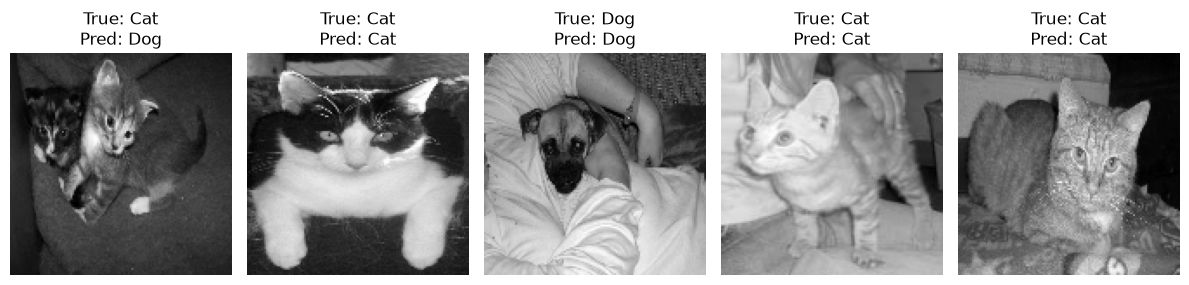

In [26]:
plt.figure(
    figsize=(12, 4)
)

for i in range(
    min(5, len(test_samples))
):

    plt.subplot(
        1,
        5,
        i + 1
    )

    plt.imshow(
        test_samples[i].reshape(
            IMG_SIZE,
            IMG_SIZE
        ),
        cmap='gray'
    )

    probability_cat = (
        inference_predictions[i][0]
    )

    predicted_class = (
        "Cat"
        if probability_cat >= 0.5
        else "Dog"
    )

    true_class = (
        "Cat"
        if true_labels[i] == 1
        else "Dog"
    )

    plt.title(
        f"True: {true_class}\n"
        f"Pred: {predicted_class}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()